# Analysis of Results



In [2]:
import pandas as pd
import json
from pathlib import Path
from dataclasses import dataclass
import matplotlib.pyplot as plt
import numpy as np
import csv
import sshfs
from dotenv import load_dotenv
import os
import qvarnet
load_dotenv()  # Load environment variables from .env file
print(os.getcwd())
if os.getenv('MOUNTPOINT') is None:
    raise ValueError("MOUNTPOINT environment variable is not set.")
import utils

/home/pfargas/Desktop/PhD/data_analysis


## Change to the directory where the results are stored

In [3]:
os.chdir(os.getenv('MOUNTPOINT'))
print(os.getcwd())

/home/pfargas/Desktop/PhD/ferrangpu_mountpoint/parameter_exploration_grid_search_mlp_ho


## Data loading and processing

### Loading results in a dataframe

In [3]:
df = utils.load_simulation_results('./out/20260211_142926')
print(df.head())

   seed  total_energy        std  training_time_seconds  best_score  \
0    42      4.945078   0.029170              37.306880    5.003418   
1    42      6.771439   3.247341              21.231098   13.266122   
2    42    -12.409181  44.761726              58.488069   77.114273   
3    42     25.439013   2.698295             220.803711   30.835602   
4    42     21.988161   3.467000              41.876789   28.922161   

                                                path  \
0  out/20260211_142926/config_64_hu_2_l_10_partic...   
1  out/20260211_142926/config_32_hu_1_l_10_partic...   
2  out/20260211_142926/config_16_hu_1_l_100_parti...   
3  out/20260211_142926/config_32_hu_1_l_200_parti...   
4  out/20260211_142926/config_4_hu_1_l_50_particl...   

                     model_type model_architecture model_activation  \
0  exponential-mlp-fourth-decay    [10, 64, 64, 1]             tanh   
1  exponential-mlp-fourth-decay        [10, 32, 1]             tanh   
2  exponential-mlp-four

### Cleaning and transforming the data

In [4]:
df = utils.separate_input_dim_and_hidden_dim(df)
df = utils.add_energy_per_particle(df)
df = utils.clean_non_informative_columns(df)

Column 'seed' has only 1 unique group size, dropping.
Column 'model_type' has only 1 unique group size, dropping.
Column 'model_activation' has only 1 unique group size, dropping.
Column 'training_num_epochs' has only 1 unique group size, dropping.
Column 'sampler_type' has only 1 unique group size, dropping.
Column 'sampler_PBC' has only 1 unique group size, dropping.
Column 'optimizer_type' has only 1 unique group size, dropping.


In [5]:
df.head()

,total_energy,std,training_time_seconds,best_score,path,training_batch_size,sampler_step_size,sampler_chain_length,optimizer_learning_rate,input_dim,hidden_dim,energy_per_particle,std_energy_per_particle,best_score_per_particle
0,4.945078,0.029170,37.306880,5.003418,out/20260211_142926/config_64_hu_2_l_10_partic...,500,0.10,150,0.0100,10,"[64, 64]",0.494508,0.002917,0.500342
1,6.771439,3.247341,21.231098,13.266122,out/20260211_142926/config_32_hu_1_l_10_partic...,1000,0.50,150,0.0001,10,[32],0.677144,0.324734,1.326612
2,-12.409181,44.761726,58.488069,77.114273,out/20260211_142926/config_16_hu_1_l_100_parti...,500,0.10,125,0.0001,100,[16],-0.124092,0.447617,0.771143
3,25.439013,2.698295,220.803711,30.835602,out/20260211_142926/config_32_hu_1_l_200_parti...,500,0.50,150,0.0100,200,[32],0.127195,0.013491,0.154178
4,21.988161,3.467000,41.876789,28.922161,out/20260211_142926/config_4_hu_1_l_50_particl...,1000,0.05,125,0.0100,50,[4],0.439763,0.069340,0.578443


## Data visualization and analysis

In [20]:
test_row = utils.localize_element_in_dataframe(df, 10, "[64, 64]", 0.01, 150, 0.5)
current_path = test_row['path']
print(current_path)

Filtering for input_dim = 10
Filtering for hidden_dim = [64, 64]
Filtering for optimizer_learning_rate = 0.01
Filtering for sampler_chain_length = 150
Filtering for sampler_step_size = 0.5
No filter applied for training_batch_size
Found 3 matching rows. Returning all of them.
2929    out/20260211_142926/config_64_hu_2_l_10_partic...
5077    out/20260211_142926/config_64_hu_2_l_10_partic...
5266    out/20260211_142926/config_64_hu_2_l_10_partic...
Name: path, dtype: str


Reading energy history from: out/20260211_142926/config_64_hu_2_l_10_particles_0.01_lr_1000_nchain_150_nstep_5000_epochs_0.5_stepsize/config_64_hu_2_l_10_particles_0.01_lr_1000_nchain_150_nstep_5000_epochs_0.5_stepsize


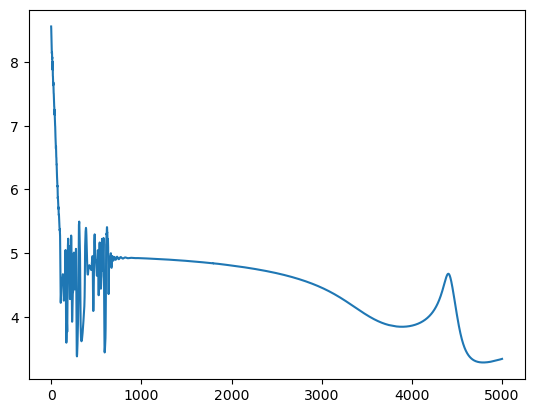

In [21]:
energy_history = utils.get_energy_history(current_path.iloc[0])
plt.plot(energy_history)

In [22]:
model, jax_params, input_dim = utils.load_model_from_path(current_path.iloc[0])
print(model)

ExponentialMLPwithPenalty(
    # attributes
    architecture = [10, 64, 64, 1]
    hidden_activation = tanh
    kernel_init = init
    bias_init = zeros
)


Shape of psi_values_array: (10, 200, 1)
Shape of psi_values_mean: (200,)
Shape of psi_values_std: (200,)


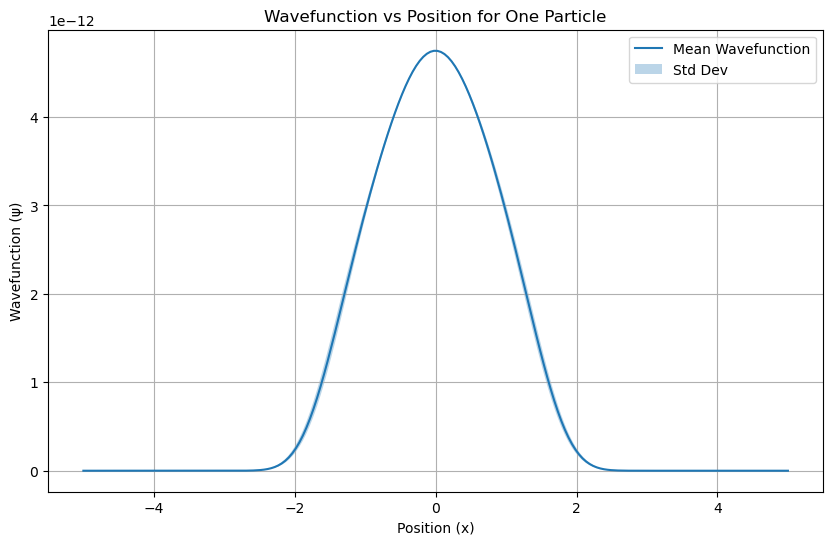

In [23]:
utils.plot_wavefunction_one_particle(model, jax_params, input_dim)

In [24]:
test_row.iloc[0]

total_energy                                                        3.281199
std                                                                 0.199101
training_time_seconds                                              53.048635
best_score                                                            3.6794
path                       out/20260211_142926/config_64_hu_2_l_10_partic...
training_batch_size                                                     1000
sampler_step_size                                                        0.5
sampler_chain_length                                                     150
optimizer_learning_rate                                                 0.01
input_dim                                                                 10
hidden_dim                                                          [64, 64]
energy_per_particle                                                  0.32812
std_energy_per_particle                                              0.01991